# 02 - Model Selection, Stacking, and Optimization

This notebook builds on the EDA, feature engineering, and baseline modeling from `01_eda_and_ baseline_model.ipynb`. The focus here is model comparison, hyperparameter optimization, probability post-processing, and testing whether ensembling improves validation performance.

Initial modeling plan:

- Use the strongest feature set identified in notebook 01.
- Compare RealMLP, CatBoost, RandomForest, and LightGBM under the same preprocessing and validation setup.
- Keep preprocessing inside reusable scikit-learn pipelines where possible.
- Use out-of-fold probabilities for probability weighting and stacking experiments.
- Select the final submission model based on validation performance, simplicity, and leaderboard feedback.

## Setup

In [116]:
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

RANDOM_STATE = 1

## Load Data

In [117]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

train_ids = train_df.pop("id")
test_ids = test_df.pop("id")

y = train_df.pop("class")
X = train_df.copy()
X_test = test_df.copy()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(X.shape, X_test.shape)
display(X.head())
display(pd.Series(y).value_counts(normalize=True).rename("class_proportion"))

(577347, 10) (247435, 10)


,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence


class
GALAXY    0.653818
QSO       0.202899
STAR      0.143283
Name: class_proportion, dtype: float64

## Preprocessing Strategy

Notebook 01 found that the synthetic categorical features did not improve validation performance, while circular encoding of `alpha` gave a small gain. I therefore keep preprocessing intentionally simple and consistent across all models: encode `alpha` as sine/cosine, drop the original `alpha`, and remove the synthetic categorical columns.

In [118]:
class AlphaSinCosTransformer(BaseEstimator, TransformerMixin):
    """Replace alpha degrees with sine/cosine features."""

    def __init__(self, alpha_col="alpha", drop_original=True):
        self.alpha_col = alpha_col
        self.drop_original = drop_original

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        alpha_rad = np.deg2rad(X[self.alpha_col])
        X["alpha_sin"] = np.sin(alpha_rad)
        X["alpha_cos"] = np.cos(alpha_rad)

        if self.drop_original:
            X = X.drop(columns=[self.alpha_col])

        return X


class DropColumnsTransformer(BaseEstimator, TransformerMixin):
    """Drop columns if they are present, so train/test transforms stay aligned."""

    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=self.columns, errors="ignore")


preprocess_pipeline = Pipeline(
    steps=[
        ("alpha_sin_cos", AlphaSinCosTransformer()),
        ("drop_synthetic_categoricals", DropColumnsTransformer(["spectral_type", "galaxy_population"])),
    ]
)

In [119]:
X_processed = preprocess_pipeline.fit_transform(X, y_encoded)
X_test_processed = preprocess_pipeline.transform(X_test)

print(X_processed.shape, X_test_processed.shape)
display(X_processed.head())


(577347, 9) (247435, 9)


c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


,delta,u,g,r,i,z,redshift,alpha_sin,alpha_cos
0,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,0.533847,-0.845581
1,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,0.788132,-0.615506
2,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,0.003619,-0.999993
3,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,-0.717133,-0.696936
4,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,0.617913,-0.786247


## Baseline Model Comparison

I compare four model families with minimal tuning: LightGBM, CatBoost, RandomForest, and RealMLP. Each model is wrapped in the same preprocessing pipeline so that validation results are comparable and preprocessing is applied independently inside each fold.

In [120]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from pytabkit import RealMLP_TD_Classifier

In [121]:
models = {
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ),

    "lightgbm": LGBMClassifier(
        objective="multiclass",
        num_class=3,
        n_estimators=500,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),

    "catboost": CatBoostClassifier(
        loss_function="MultiClass",
        iterations=500,
        learning_rate=0.05,
        random_seed=RANDOM_STATE,
        verbose=False,
    ),

    "realmlp": RealMLP_TD_Classifier(
        n_epochs=32,
        random_state=RANDOM_STATE,
        verbosity=0,
    )
}

In [122]:
model_pipelines = {
    name: Pipeline(steps=[
        ("preprocess", preprocess_pipeline),
        ("model", model),
    ])
    for name, model in models.items()
}

## Out-of-Fold Evaluation

I use stratified 5-fold cross-validation to preserve the target class distribution across folds. For each model, I store out-of-fold class probabilities and predictions. These OOF probabilities are useful later for probability weighting and stacking experiments.

In [123]:
from tqdm.notebook import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import balanced_accuracy_score

In [124]:


def evaluate_model_oof(name, pipeline, X, y, skf):

    oof_preds = np.empty(len(y), dtype=int)
    oof_probs = np.empty((len(y), len(np.unique(y))), dtype=float)
    fold_scores = []

    for fold, (train_idx, test_idx) in tqdm(enumerate(skf.split(X, y), start=1)):

        X_train, X_test, y_train, y_test = X.iloc[train_idx], X.iloc[test_idx], y[train_idx], y[test_idx]
        p = clone(pipeline)
        p.fit(X_train, y_train)

        probs = p.predict_proba(X_test)
        preds = probs.argmax(axis=1)

        oof_preds[test_idx] = preds; oof_probs[test_idx] = probs


        score = balanced_accuracy_score(y_test, preds)
        fold_scores.append(score)
    mean_score = np.mean(fold_scores); std_score = np.std(fold_scores)



    return {
        "model": name,
        "oof_probs": oof_probs,
        "oof_preds": oof_preds,
        "fold_scores": fold_scores,
        "mean_score": mean_score,
        "std_score": std_score,

    }

In [125]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

oof_results = {}

for name, p in tqdm(model_pipelines.items()):

    oof_results[name] = evaluate_model_oof(name, p, X, y_encoded, skf)
    

  0%|          | 0/4 [00:00<?, ?it/s]

0it [00:00, ?it/s]

c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c

0it [00:00, ?it/s]

c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c

0it [00:00, ?it/s]

c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c

0it [00:00, ?it/s]

c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=32` reached.
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Us

In [126]:
model_scores = pd.DataFrame([
    {
        "model": name,
        "mean_balanced_accuracy": result["mean_score"],
        "std_balanced_accuracy": result["std_score"],
    }
    for name, result in oof_results.items()
]).sort_values("mean_balanced_accuracy", ascending=False)

model_scores

,model,mean_balanced_accuracy,std_balanced_accuracy
1,lightgbm,0.953469,0.000440
3,realmlp,0.945750,0.001147
0,random_forest,0.945328,0.000480
2,catboost,0.942336,0.000801


              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98    377480
         QSO       0.97      0.96      0.96    117143
        STAR       0.92      0.92      0.92     82724

    accuracy                           0.97    577347
   macro avg       0.95      0.95      0.95    577347
weighted avg       0.97      0.97      0.97    577347



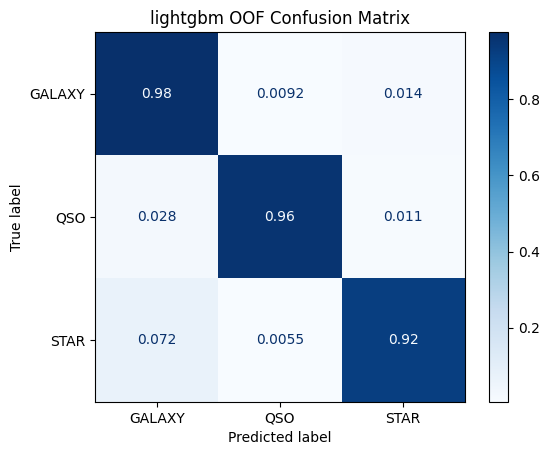

In [127]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model_name = model_scores.iloc[0]["model"]
best_result = oof_results[best_model_name]

print(classification_report(
    y_encoded,
    best_result["oof_preds"],
    target_names=label_encoder.classes_,
))

ConfusionMatrixDisplay.from_predictions(
    y_encoded,
    best_result["oof_preds"],
    display_labels=label_encoder.classes_,
    normalize="true",
    cmap="Blues",
)

plt.title(f"{best_model_name} OOF Confusion Matrix")
plt.show()

### Baseline Takeaway

LightGBM is the strongest initial model, with RandomForest and RealMLP close enough to remain useful candidates. CatBoost performs slightly worse but may still add diversity in an ensemble. Based on these results, I tune all models but keep CatBoost’s search budget smaller to control runtime.

## Hyperparameter Optimization

I use Optuna with a TPE sampler to tune model hyperparameters against mean OOF balanced accuracy. The search budgets are intentionally uneven: stronger or faster models receive more trials, while slower/lower-performing models receive fewer. This reflects a practical modeling tradeoff between performance and compute cost.

In [128]:
#https://medium.com/@cris.lincoleo/a-quick-guide-to-hyperparameter-optimization-with-optuna-1980f1d185dc

import optuna
import logging

In [129]:
from optuna.samplers import TPESampler

sampler = TPESampler()

study = optuna.create_study(
    study_name='lightgbm_optimization',
    direction="maximize",
    sampler=sampler,
)
studies = {}

[I 2026-07-22 12:01:24,375] A new study created in memory with name: lightgbm_optimization


In [130]:
def make_model_pipeline(model):
    return Pipeline(steps=[
        ("preprocess", preprocess_pipeline),
        ("model", model),
    ])

In [131]:
def objective_lightgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 128),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 150),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    model = LGBMClassifier(
        objective="multiclass",
        num_class=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
        **params,
    )

    pipeline = make_model_pipeline(model)
    result = evaluate_model_oof("lightgbm_trial", pipeline, X, y_encoded, skf)

    return result["mean_score"]
#Had an incident where I lost the HPO training for the models, though I was able to recover iterations and learning rate for CatBoost and RealMLP's final hyperparameters. 
#Since CatBoost takes such a long time but wasn't a top 2 performer, I will shorten its HPO for my sanity :>
def objective_catboost(trial):
    params = {
        #"iterations": trial.suggest_int("iterations", 300, 1200),
        #"learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-2, 20.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 2.0),
        "border_count": trial.suggest_int("border_count", 32, 255),
    }

    model = CatBoostClassifier(
        loss_function="MultiClass",
        iterations=1091,
        learning_rate=0.089559,
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
        **params,
    )

    pipeline = make_model_pipeline(model)
    result = evaluate_model_oof("catboost_trial", pipeline, X, y_encoded, skf)

    return result["mean_score"]

def objective_random_forest(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1100),
        "max_depth": trial.suggest_int("max_depth", 8, 45),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 15),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
    }

    model = RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample",
        **params,
    )
    
    pipeline = make_model_pipeline(model)
    result = evaluate_model_oof("random_forest_trial", pipeline, X, y_encoded, skf)

    return result["mean_score"]
'''
def objective_realmlp(trial):
    params = {
        "lr": trial.suggest_float("lr", 0.02, 0.30, log=True),
        "p_drop": trial.suggest_categorical("p_drop", [0.0, 0.15, 0.30]),
        "wd": trial.suggest_categorical("wd", [0.0, 0.02]),
    }

    model = RealMLP_TD_Classifier(
        random_state=RANDOM_STATE,
        verbosity=0,
        **params,
    )

    pipeline = make_model_pipeline(model)
    result = evaluate_model_oof("realmlp_trial", pipeline, X, y_encoded, skf)

    return result["mean_score"]
'''

def objective_realmlp(trial):
    params = {
        "lr": trial.suggest_float("lr", 0.02, 0.30, log=True),
        "p_drop": trial.suggest_categorical("p_drop", [0.0, 0.15, 0.30]),
        "wd": trial.suggest_categorical("wd", [0.0, 0.02]),
        "hidden_sizes": list(trial.suggest_categorical(
            "hidden_sizes",
            [
                (256, 256, 256),
                (64, 64, 64, 64, 64),
                (512,),
            ],
        )),
        "act": trial.suggest_categorical("act", ["relu", "selu", "mish"]),

        # Keep RealMLP cheap inside each outer CV fold
        "n_cv": 1,
        "n_refit": 0,
        "n_ens": 1,
        "n_epochs": 8,
        "use_early_stopping": True,
        "val_metric_name": "cross_entropy",
    }

    model = RealMLP_TD_Classifier(
        random_state=RANDOM_STATE,
        verbosity=0,
        **params,
    )

    pipeline = make_model_pipeline(model)
    result = evaluate_model_oof("realmlp_stage1", pipeline, X, y_encoded, skf)

    return result["mean_score"]

In [132]:
objective_functions = {
    "lightgbm": objective_lightgbm,
    "catboost": objective_catboost,
    "random_forest": objective_random_forest,
    "realmlp": objective_realmlp,
}

### Recovered RealMLP Parameters

During experimentation, the persisted Optuna study file was accidentally overwritten. The RealMLP best parameters were recoverable from notebook output, so I reconstruct them here to keep the downstream comparison complete.

In [133]:
from types import SimpleNamespace

studies = {
    "realmlp": SimpleNamespace(
        best_value=0.9438964679356528,
        best_params={
            "lr": 0.044376911172822546,
            "p_drop": 0.15,
            "wd": 0.0,
            "hidden_sizes": (256, 256, 256),
            "act": "mish",
        },
        trials=[None] * 30,
    )
}

In [ ]:
hpo_trials = {
    "lightgbm": 50,
    "catboost": 8,
    "random_forest": 30,
    "realmlp": 30,
}

if "studies" not in globals():
    studies = {}

for model_name, objective in objective_functions.items():
    if model_name in studies:
        print(f"Skipping {model_name}; study already exists.")
        continue

    model_study = optuna.create_study(
        study_name=f"{model_name}_optimization",
        direction="maximize",
        sampler=TPESampler(seed=RANDOM_STATE, multivariate=True),
    )

    model_study.optimize(objective, n_trials=hpo_trials[model_name])

    studies[model_name] = model_study

    print(model_name)
    print("best score:", model_study.best_value)
    print("best params:", model_study.best_params)

c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2026-07-17 20:48:39,605] A new study created in memory with name: lightgbm_optimization


0it [00:00, ?it/s]

c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c

0it [00:00, ?it/s]

c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c

...

0it [00:00, ?it/s]

c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c

0it [00:00, ?it/s]

c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c

random_forest
best score: 0.9579947618786699
best params: {'n_estimators': 604, 'max_depth': 27, 'min_samples_split': 29, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': False}
Skipping realmlp; study already exists.


In [ ]:
hpo_summary = pd.DataFrame([
    {
        "model": name,
        "best_hpo_score": study.best_value,
        "n_trials": len(study.trials),
        "best_params": study.best_params,
    }
    for name, study in studies.items()
]).sort_values("best_hpo_score", ascending=False)

hpo_summary

,model,best_hpo_score,n_trials,best_params
3,random_forest,0.957995,30,"{'n_estimators': 604, 'max_depth': 27, 'min_sa..."
1,lightgbm,0.957882,50,"{'n_estimators': 825, 'learning_rate': 0.03934..."
2,catboost,0.953459,8,"{'depth': 10, 'l2_leaf_reg': 0.019086816256379..."
0,realmlp,0.943896,30,"{'lr': 0.044376911172822546, 'p_drop': 0.15, '..."


## Tuned Model Evaluation

After HPO, I rebuild each model using its selected hyperparameters and rerun the same OOF evaluation. This gives a fair comparison between baseline and tuned models under the same validation procedure.

In [134]:
stored_studies = studies.copy()

In [ ]:
import pickle
from pathlib import Path

study_path = Path("../data/optuna_studies.pkl")
if studies is not None:
    with open(study_path, "wb") as f:
        pickle.dump(studies, f)

    print(f"Saved studies to {study_path}")

Saved studies to ..\data\optuna_studies.pkl


In [135]:
with open(study_path, "rb") as f:
    HPO_studies = pickle.load(f)

In [138]:
best_models = {
    "lightgbm": LGBMClassifier(
        objective="multiclass",
        num_class=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **HPO_studies['lightgbm'].best_params,
    ),

    "catboost": CatBoostClassifier(
        loss_function="MultiClass",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
        **HPO_studies['catboost'].best_params,
    ),

    "random_forest": RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample",
        **HPO_studies['random_forest'].best_params,
    )
}
realmlp_params = HPO_studies["realmlp"].best_params.copy()

if "hidden_sizes" in realmlp_params:
    realmlp_params["hidden_sizes"] = list(realmlp_params["hidden_sizes"])

realmlp_params.update(
    {
        "n_epochs": 32,
        "n_cv": 1,
        "n_refit": 0,
        "n_ens": 1,
        "use_early_stopping": True,
        "val_metric_name": "cross_entropy",
    }
)

best_models["realmlp"] = RealMLP_TD_Classifier(
    random_state=RANDOM_STATE,
    verbosity=0,
    **realmlp_params,
)

In [139]:
best_model_pipelines = {
    name: Pipeline(steps=[
        ("preprocess", preprocess_pipeline),
        ("model", model),
    ])
    for name, model in best_models.items()
}

In [140]:
def run_pipelines(pipelines, oofs=None):
    if oofs is None:
        oofs = {}

    for name, pipeline in tqdm(pipelines.items()):
        if name in oofs:
            print(f"Skipping {name}; OOF result already exists.")
            continue

        oofs[name] = evaluate_model_oof(
            name,
            pipeline,
            X,
            y_encoded,
            skf,
        )

    return oofs

In [ ]:
if "oof_results_best" not in globals():
    oof_results_best = {}

saved_oofs = oof_results_best.copy()

In [ ]:
oof_results_best = run_pipelines(
    best_model_pipelines,
    oofs=saved_oofs,
)

  0%|          | 0/4 [00:00<?, ?it/s]

0it [00:00, ?it/s]

c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c

0it [00:00, ?it/s]

c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c

0it [00:00, ?it/s]

c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c

0it [00:00, ?it/s]

c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=32` reached.
c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Us

In [ ]:
best_model_scores = pd.DataFrame([
    {
        "model": name,
        "mean_balanced_accuracy": result["mean_score"],
        "std_balanced_accuracy": result["std_score"],
    }
    for name, result in oof_results_best.items()
]).sort_values("mean_balanced_accuracy", ascending=False)

In [ ]:
best_model_scores

,model,mean_balanced_accuracy,std_balanced_accuracy
2,random_forest,0.957995,0.000373
0,lightgbm,0.957882,0.000612
1,catboost,0.950952,0.000732
3,realmlp,0.942756,0.002032


The tuned models improve over the initial baselines, with LightGBM and RandomForest remaining the strongest candidates. Since the model scores are close, I keep all tuned probability outputs available for post-processing and stacking experiments, but LightGBM remains the primary benchmark to beat.

## Probability Weighting With Differential Evolution

The target metric is balanced accuracy, which can benefit from adjusting class decision thresholds. I use differential evolution to learn class weights applied to predicted probabilities. To avoid relying only on an optimistic in-sample estimate, I also estimate the weighted score with a cross-validated procedure over the OOF predictions.

In [ ]:
from scipy.optimize import differential_evolution
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

def predict_with_class_weights(probs, weights):
    probs = np.asarray(probs, dtype=float)
    weights = np.asarray(weights, dtype=float)
    return (probs * weights).argmax(axis=1)


def optimize_class_weights(probs, y_true, seed=42):
    probs = np.asarray(probs, dtype=float)
    y_true = np.asarray(y_true)

    def objective(weights):
        preds = predict_with_class_weights(probs, weights)
        return -balanced_accuracy_score(y_true, preds)

    result = differential_evolution(
        objective,
        bounds=[(0.5, 2.0), (0.5, 2.0), (0.5, 2.0)],
        seed=seed,
        tol=1e-7,
    )

    weights = result.x
    score = -result.fun

    return weights, score

In [ ]:
def cv_optimize_class_weights(model_name, probs, y_true, n_splits=5, seed=1):
    probs = np.asarray(probs, dtype=float)
    y_true = np.asarray(y_true)
    
    skf_de = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=seed,
    )

    calibrated_oof_preds = np.empty(len(y_true), dtype=int)
    fold_weight_rows = []

    for fold, (train_idx, valid_idx) in tqdm(
        enumerate(skf_de.split(probs, y_true), start=1),
        total=n_splits,
    ):
        fold_weights, inner_score = optimize_class_weights(
            probs[train_idx],
            y_true[train_idx],
            seed=fold,
        )

        valid_preds = predict_with_class_weights(
            probs[valid_idx],
            fold_weights,
        )

        calibrated_oof_preds[valid_idx] = valid_preds

        valid_score = balanced_accuracy_score(
            y_true[valid_idx],
            valid_preds,
        )

        fold_weight_rows.append({
            "model": model_name,
            "fold": fold,
            "galaxy_weight": fold_weights[0],
            "qso_weight": fold_weights[1],
            "star_weight": fold_weights[2],
            "inner_train_score": inner_score,
            "heldout_score": valid_score,
        })

    weight_cv_results = pd.DataFrame(fold_weight_rows)

    cv_weighted_score = balanced_accuracy_score(
        y_true,
        calibrated_oof_preds,
    )

    final_weights, final_score = optimize_class_weights(
        probs,
        y_true,
        seed=seed,
    )

    return {
        "model": model_name,
        "cv_weighted_preds": calibrated_oof_preds,
        "cv_weighted_score": cv_weighted_score,
        "weight_cv_results": weight_cv_results,
        "final_weights": final_weights,
        "final_score": final_score,
    }

In [ ]:
de_results_best = {}

for model_name, result in oof_results_best.items():
    de_results_best[model_name] = cv_optimize_class_weights(
        model_name=model_name,
        probs=result["oof_probs"],
        y_true=y_encoded,
        n_splits=5,
        seed=RANDOM_STATE,
    )

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
de_final_scores = {
    name: result["final_score"]
    for name, result in de_results_best.items()
}

best_model_scores["de_final_score"] = best_model_scores["model"].map(de_final_scores)

best_model_scores["de_improvement"] = (
    best_model_scores["de_final_score"]
    - best_model_scores["mean_balanced_accuracy"]
)

best_model_scores

,model,mean_balanced_accuracy,std_balanced_accuracy,de_final_score,de_improvement
2,random_forest,0.957995,0.000373,0.959151,0.001156
0,lightgbm,0.957882,0.000612,0.966291,0.008409
1,catboost,0.950952,0.000732,0.961922,0.010970
3,realmlp,0.942756,0.002032,0.955390,0.012635


The results indicate that the worse the model originally was, the better the DE boosted the results. Random forest seemed to not get much benefit from DE compared to the GBDTs causing it to fall below LightGBM and CatBoost in terms of performance.

## Stacking Experiments

Because each model produces OOF probabilities, I test whether a simple logistic regression meta-learner can improve performance by combining model outputs. This experiment does not improve over the best LightGBM + probability-weighted model, so I do not use stacking in the final submission.

In [ ]:
import warnings

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="sklearn.linear_model._logistic",
)

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="sklearn.linear_model._logistic",
)

In [70]:
def apply_class_weights_to_probs(probs, weights, normalize=True):
    weighted_probs = np.asarray(probs, dtype=float) * np.asarray(weights, dtype=float)

    if normalize:
        weighted_probs = weighted_probs / weighted_probs.sum(axis=1, keepdims=True)

    return weighted_probs

In [ ]:
de_prob_results = {}

for model_name, result in oof_results_best.items():
    weights = de_results_best[model_name]["final_weights"]

    raw_probs = np.asarray(result["oof_probs"], dtype=float)
    weighted_probs = apply_class_weights_to_probs(raw_probs, weights)

    weighted_preds = weighted_probs.argmax(axis=1)

    de_prob_results[model_name] = {
        "weighted_probs": weighted_probs,
        "weighted_preds": weighted_preds,
        "weights": weights,
        "weighted_score": balanced_accuracy_score(y_encoded, weighted_preds),
        "raw_score": result["mean_score"],
    }

In [ ]:
de_prob_summary = pd.DataFrame([
    {
        "model": model_name,
        "raw_score": result["raw_score"],
        "de_weighted_score": result["weighted_score"],
        "improvement": result["weighted_score"] - result["raw_score"],
        "weights": result["weights"],
    }
    for model_name, result in de_prob_results.items()
]).sort_values("de_weighted_score", ascending=False)

de_prob_summary

,model,raw_score,de_weighted_score,improvement,weights
0,lightgbm,0.957882,0.966291,0.008409,"[0.5085041648753669, 1.4960840738917924, 1.996..."
1,catboost,0.950952,0.961922,0.010970,"[0.5021425020487598, 1.6365887810196003, 1.986..."
2,random_forest,0.957995,0.959151,0.001156,"[1.2748693890471319, 1.9877392216432415, 1.817..."
3,realmlp,0.942756,0.955390,0.012635,"[0.5002245496759024, 1.5446537450122466, 1.994..."


In [ ]:
de_prob_summary["model"].tolist()

['lightgbm', 'catboost', 'random_forest', 'realmlp']

In [ ]:
stack_model_order = de_prob_summary["model"].tolist()

stack_X_raw = np.hstack([
    np.asarray(oof_results_best[model_name]["oof_probs"], dtype=float)
    for model_name in stack_model_order
])

stack_X_de = np.hstack([
    de_prob_results[model_name]["weighted_probs"]
    for model_name in stack_model_order
])

stack_X_raw_plus_de = np.hstack([stack_X_raw, stack_X_de])

data_stacks = {
    'X_raw' : stack_X_raw,
    'X_de' : stack_X_de,
    'X_raw_de' : stack_X_raw_plus_de
}

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

stacker = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    class_weight="balanced",
)
def logistic_meta_learner(stacker, X, y, cv):
    stack_scores = cross_val_score(
        stacker,
        X,
        y,
        cv=cv,
        scoring="balanced_accuracy",
    )
    return stack_scores


In [ ]:
for name, data in data_stacks.items():
    stack_scores = logistic_meta_learner(stacker, data, y_encoded, skf)
    
    print(f" {name} | mean: {stack_scores.mean()} | std: {stack_scores.std()}")

 X_raw | mean: 0.9639712263605269 | std: 0.0003908575220979516
 X_de | mean: 0.9660935838788962 | std: 0.0003006687481952967
 X_raw_de | mean: 0.9657862748392253 | std: 0.00041510227360083674


In [ ]:
lgbm_rf = np.hstack([de_prob_results['lightgbm']["weighted_probs"], de_prob_results['random_forest']["weighted_probs"]])
lgbm_rf_score = logistic_meta_learner(stacker, lgbm_rf, y, skf)
lgbm_rf_score.mean()

np.float64(0.9660052814114698)

The logistic regression meta-learner did not improve over LightGBM + DE. The best stack variant scored approximately 0.9661, while LightGBM + DE scored 0.9663. I therefore avoid adding ensemble complexity to the final submission.

## Final Model Selection

The best practical result comes from tuned LightGBM with differential-evolution class weighting. Although stacking was explored, it did not improve validation performance. I therefore select the simpler LightGBM + DE approach for the final Kaggle submission.

In [91]:
lightgbm_final_model = LGBMClassifier(
    objective="multiclass",
    num_class=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
    **studies["lightgbm"].best_params,
)

lightgbm_final_pipeline = make_model_pipeline(lightgbm_final_model)

lightgbm_final_pipeline.fit(X, y_encoded)

test_probs = lightgbm_final_pipeline.predict_proba(X_test)

lightgbm_de_weights = de_results_best["lightgbm"]["final_weights"]

test_probs_de = test_probs * lightgbm_de_weights
test_preds_de = test_probs_de.argmax(axis=1)

test_pred_labels = label_encoder.inverse_transform(test_preds_de)

submission = pd.DataFrame(
    {
        "id": test_ids,
        "class": test_pred_labels,
    }
)

submission_path = "../data/submission_lightgbm_hpo_de.csv"
submission.to_csv(submission_path, index=False)

submission.head(), submission_path

c:\Users\chris\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


(       id   class
 0  577347  GALAXY
 1  577348  GALAXY
 2  577349  GALAXY
 3  577350    STAR
 4  577351  GALAXY,
 '../data/submission_lightgbm_hpo_de.csv')

The final LightGBM + HPO + differential-evolution submission achieved:

- Public leaderboard: 0.96741
- Private leaderboard: 0.96694
- Approximate private rank: 714 / 2817